In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import cv2
import seaborn as sns

In [2]:
DATASET_PATH = "./dataset"
batch_size = 32
#Not really 200, early stopping will take care of it.
num_epochs = 200
learning_rate = 0.0001

In [3]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
def load_dataset(dataset_path, image_size=(128, 128), rgb=False):
    dataset_path = Path(dataset_path)
    class_names = sorted(path.name for path in dataset_path.iterdir() if path.is_dir())
    class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
    images = []
    labels = []
    for class_name in class_names:
        class_dir = dataset_path / class_name
        for image_path in sorted(class_dir.glob("*.jpg")):
            if rgb:
                image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
            else:
                image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            # Crop the data not important
            image = image[282:1517, 70:2173]
            if image is None:
                continue
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(class_to_idx[class_name])
    return np.array(images), np.array(labels), np.array(class_names), class_to_idx

In [5]:
images, labels, class_names, class_to_idx = load_dataset(DATASET_PATH)

#Used for resnet
images_rgb, labels_rgb, class_names_rgb, class_to_idx_rgb = load_dataset(DATASET_PATH, (128, 128), True)

In [6]:
print(f"Loaded {len(images)} images")
print(f"Image tensor shape: {tuple(images.shape)}")
print(f"Classes: {class_names}")

Loaded 928 images
Image tensor shape: (928, 128, 128)
Classes: ['AHB' 'HMI' 'MI' 'Normal']


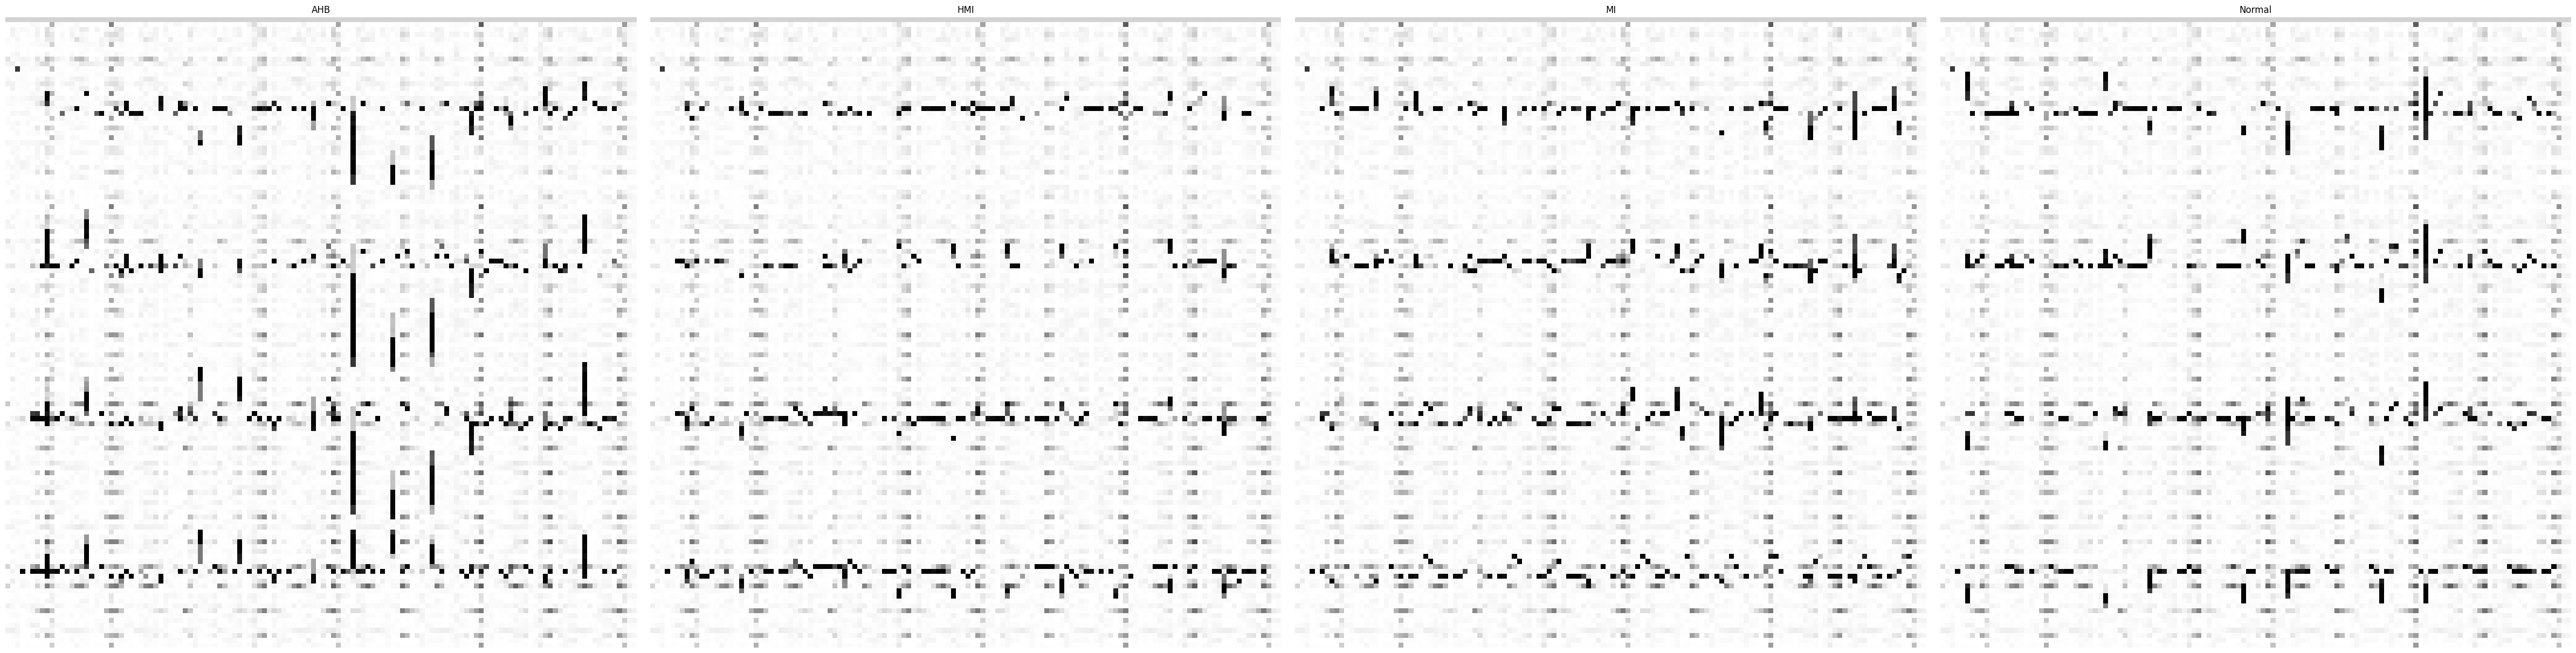

In [7]:
#Displaying sample images from each class
fig, axes = plt.subplots(1, len(class_names), figsize=(12 * len(class_names), 12))
for idx, class_name in enumerate(class_names):
    sample_index = np.where(labels == idx)[0][0]
    axes[idx].imshow(images[sample_index], cmap="gray")
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [8]:
class_counts = {class_name: int(np.sum(labels == idx)) for idx, class_name in enumerate(class_names)}
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

AHB: 233 images
HMI: 172 images
MI: 239 images
Normal: 284 images


In [9]:
# Define transforms with augmentation for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),  # Convert numpy to PIL for augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# No augmentation for validation/test
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [10]:
class ECGDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        
        if self.transform:
            sample = self.transform(sample)
        
        return sample, label

In [11]:
# Split the dataset into training, test, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train_rgb, X_temp_rgb, y_train_rgb, y_temp_rgb = train_test_split(images_rgb, labels_rgb, test_size=0.2, random_state=42, stratify=labels_rgb)
X_val_rgb, X_test_rgb, y_val_rgb, y_test_rgb = train_test_split(X_temp_rgb, y_temp_rgb, test_size=0.5, random_state=42, stratify=y_temp_rgb)

In [12]:
#Create dataset
train_dataset = ECGDataset(X_train, y_train, transform=train_transform)
val_dataset = ECGDataset(X_val, y_val, transform=val_transform)
test_dataset = ECGDataset(X_test, y_test, transform=val_transform)

train_dataset_rgb = ECGDataset(X_train_rgb, y_train_rgb, transform=train_transform)
val_dataset_rgb = ECGDataset(X_val_rgb, y_val_rgb, transform=val_transform)
test_dataset_rgb = ECGDataset(X_test_rgb, y_test_rgb, transform=val_transform)

In [13]:
# Weighted random sampler
class_sample_count = torch.tensor([(y_train == t).sum() for t in np.unique(y_train)])
weight = 1. / class_sample_count.float()
samples_weight = torch.tensor([weight[t] for t in torch.tensor(y_train)])
sampler = torch.utils.data.WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, drop_last=True)
train_loader_rgb = DataLoader(train_dataset_rgb, batch_size=batch_size, sampler=sampler, drop_last=True)

In [14]:
val_loader = DataLoader(val_dataset, batch_size=batch_size, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, drop_last=False)

val_loader_rgb = DataLoader(val_dataset_rgb, batch_size=batch_size, drop_last=False)
test_loader_rgb = DataLoader(test_dataset_rgb, batch_size=batch_size, drop_last=False)

### ResNet Finetune example:

In [23]:
resnet = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in resnet.parameters():
    param.requires_grad = False

for param in resnet.layer2.parameters():
    param.requires_grad = True

for param in resnet.layer3.parameters():
    param.requires_grad = True

for param in resnet.layer4.parameters():
    param.requires_grad = True

In [24]:
num_ftrs = resnet.fc.in_features
criterion = nn.CrossEntropyLoss()
resnet.fc = nn.Linear(num_ftrs, len(class_names))
resnet = resnet.to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [25]:
# Training
best_val_loss = float('inf')
patience = 15
patience_counter = 0
loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    resnet.train()
    epoch_loss = 0.0
    num_batches = 0
    for i, data in enumerate(train_loader_rgb, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    avg_epoch_loss = epoch_loss / num_batches
    
    # VALIDATION
    resnet.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in val_loader_rgb:
            inputs, labels = data

            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = resnet(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    # Learning rate scheduler step
    scheduler.step(avg_val_loss)
    # Print epoch summary
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'  Training Loss:   {avg_epoch_loss:.4f}')
    print(f'  Validation Loss: {avg_val_loss:.4f}')
    print(f'  Learning Rate:   {optimizer.param_groups[0]["lr"]:.6f}')
    print('-' * 50)
    loss_history.append(avg_epoch_loss)
    val_loss_history.append(avg_val_loss)
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save(resnet.state_dict(), 'best_model_resnet.pth')
        print(f'Best model saved!')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            break

print('\nFinished Training')
print(f'Best Validation Loss: {best_val_loss:.4f}')

Epoch [1/200]
  Training Loss:   1.3563
  Validation Loss: 1.3915
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [2/200]
  Training Loss:   1.2773
  Validation Loss: 1.1178
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [3/200]
  Training Loss:   1.1287
  Validation Loss: 1.0966
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [4/200]
  Training Loss:   1.0388
  Validation Loss: 1.0071
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [5/200]
  Training Loss:   0.9197
  Validation Loss: 0.8575
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [6/200]
  Training Loss:   0.9014
  Validation Loss: 0.8215
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [7/200]
  Traini

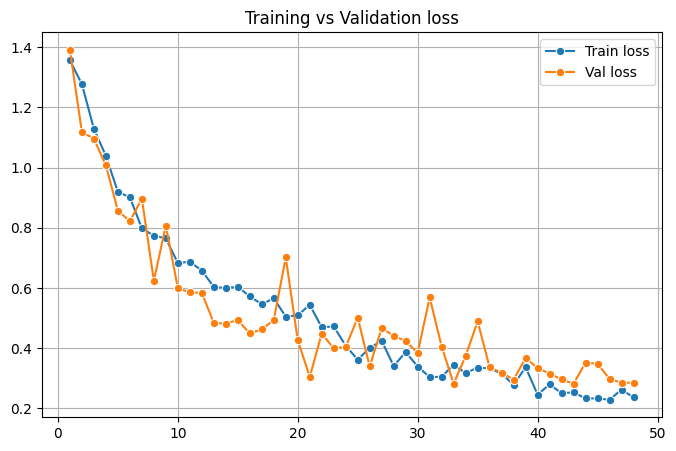

In [26]:
# Plot losses
plot_epochs = list(range(1, len(loss_history) + 1))
plt.figure(figsize=(8,5))
sns.lineplot(x=plot_epochs, y=loss_history, marker='o', label='Train loss')
sns.lineplot(x=plot_epochs, y=val_loss_history, marker='o', label='Val loss')
plt.legend()
plt.title("Training vs Validation loss")
plt.grid(True)
plt.show()

In [27]:
# Load best model
resnet.load_state_dict(torch.load('best_model_resnet.pth'))

<All keys matched successfully>

In [28]:
#Evaluate on test set
resnet.eval()
correct = 0
total = 0
all_predictions = []
all_labels = []
with torch.no_grad():
    for data in test_loader_rgb:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 90.32%


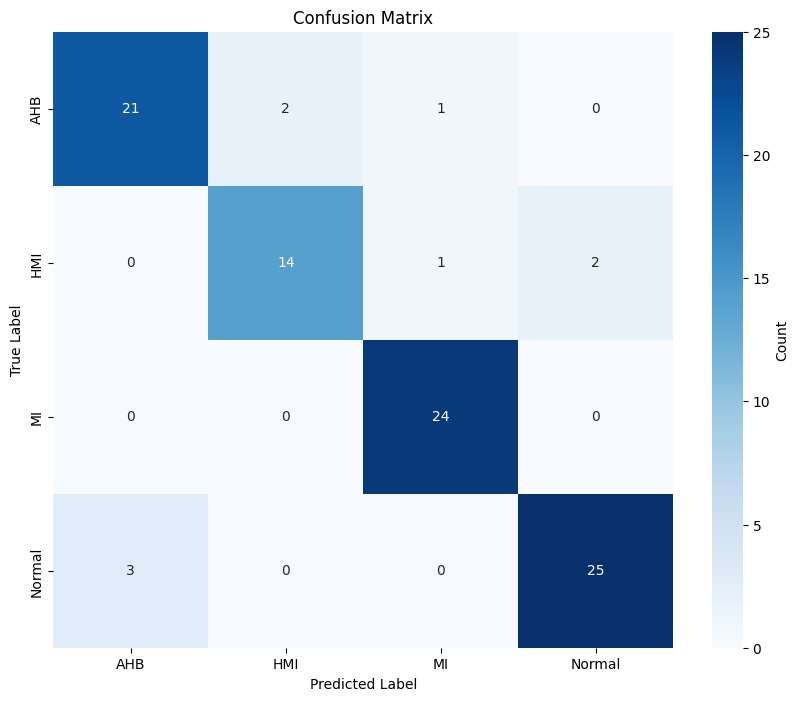

In [29]:
cm = confusion_matrix(all_labels, all_predictions)
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Custom ConvNet:

In [30]:
class ConvNet(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(ConvNet, self).__init__()
        # First conv block
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        
        # Second conv block
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Third conv block
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout2d = nn.Dropout2d(p=0.4)
        
        # Fully connected layers
        self.fc1 = nn.Linear(256 * 16 * 16, 512)
        self.bn4 = nn.BatchNorm1d(512)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(512, len(class_to_idx))

    def forward(self, x):
        # Block 1: 128x128 -> 64x64
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        
        # Block 2: 64x64 -> 32x32
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)
        
        # Block 3: 32x32 -> 16x16
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.dropout2d(x)
        
        # Fully connected
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [31]:
net = ConvNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [32]:
# Training
best_val_loss = float('inf')
patience = 15
patience_counter = 0
loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    net.train()
    epoch_loss = 0.0
    num_batches = 0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    avg_epoch_loss = epoch_loss / num_batches
    
    # VALIDATION
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data

            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    # Learning rate scheduler step
    scheduler.step(avg_val_loss)
    # Print epoch summary
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'  Training Loss:   {avg_epoch_loss:.4f}')
    print(f'  Validation Loss: {avg_val_loss:.4f}')
    print(f'  Learning Rate:   {optimizer.param_groups[0]["lr"]:.6f}')
    print('-' * 50)
    loss_history.append(avg_epoch_loss)
    val_loss_history.append(avg_val_loss)
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save best model
        torch.save(net.state_dict(), 'best_model.pth')
        print(f'Best model saved!')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            break

print('\nFinished Training')
print(f'Best Validation Loss: {best_val_loss:.4f}')

Epoch [1/200]
  Training Loss:   1.5691
  Validation Loss: 1.8112
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [2/200]
  Training Loss:   1.3735
  Validation Loss: 1.2156
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [3/200]
  Training Loss:   1.3942
  Validation Loss: 1.2881
  Learning Rate:   0.000100
--------------------------------------------------
Epoch [4/200]
  Training Loss:   1.3333
  Validation Loss: 1.2148
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [5/200]
  Training Loss:   1.3546
  Validation Loss: 1.1563
  Learning Rate:   0.000100
--------------------------------------------------
Best model saved!
Epoch [6/200]
  Training Loss:   1.3339
  Validation Loss: 1.1892
  Learning Rate:   0.000100
--------------------------------------------------
Epoch [7/200]
  Training Loss:   1.3283
  Validation Loss:

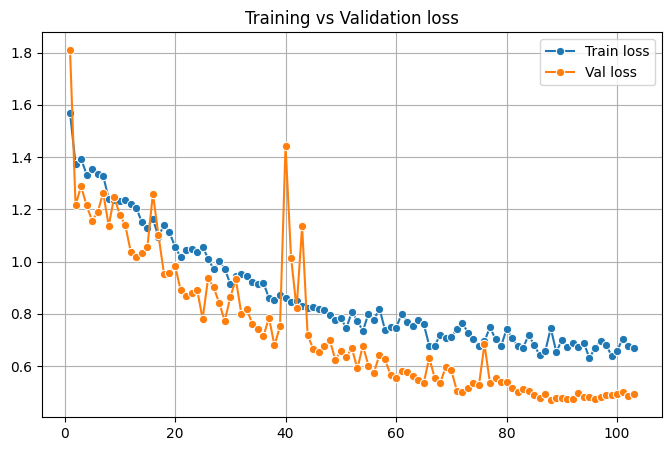

In [33]:
# Plot losses
plot_epochs = list(range(1, len(loss_history) + 1))
plt.figure(figsize=(8,5))
sns.lineplot(x=plot_epochs, y=loss_history, marker='o', label='Train loss')
sns.lineplot(x=plot_epochs, y=val_loss_history, marker='o', label='Val loss')
plt.legend()
plt.title("Training vs Validation loss")
plt.grid(True)
plt.show()

In [34]:
# Load best model
net.load_state_dict(torch.load('best_model.pth'))

<All keys matched successfully>

In [35]:
#Evaluate on test set
resnet.eval()
correct = 0
total = 0
all_predictions = []
all_labels = []
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = net(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
test_accuracy = 100 * correct / total
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 79.57%


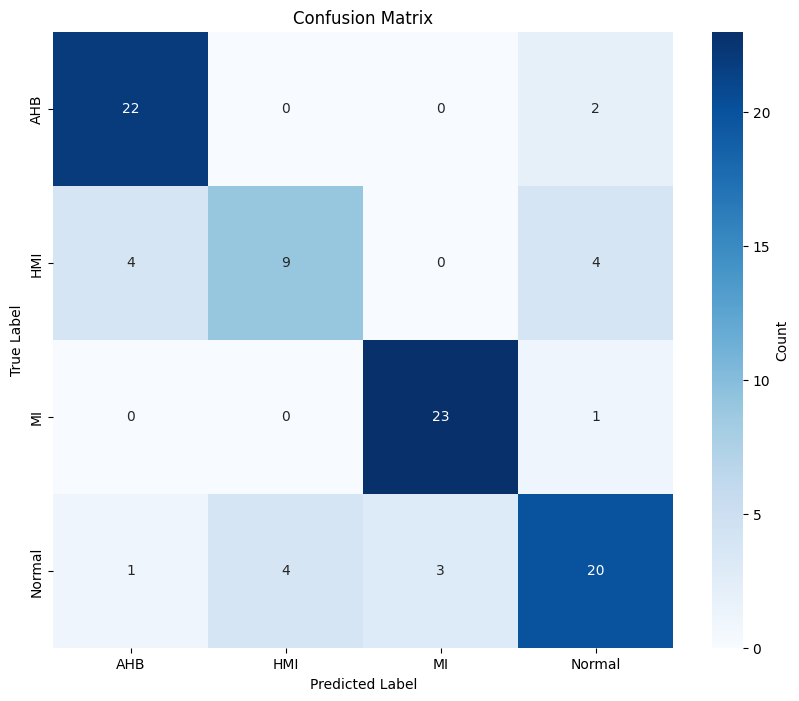

In [36]:
cm = confusion_matrix(all_labels, all_predictions)
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in range(len(class_to_idx))]
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()